In [1]:
# help for the project https://medium.com/@christopherha7/telco-customer-churn-analysis-80475aa6c7f8

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import math
from matplotlib.patches import FancyArrowPatch
from matplotlib.ticker import FixedLocator
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("telecom_customer_churn.csv")

In [4]:
# 1. Isolate the population (Exclude Joined)
analysis_df = df[df['Customer Status'].isin(['Stayed', 'Churned'])].copy()

# 2. Corrected Normalised Value Factor (NVF)
norm_df = analysis_df[['Customer ID', 'Monthly Charge', 'Tenure in Months', 'Number of Referrals', 'Customer Status']].copy()
norm_df.columns = ['Customer ID', 'MonthlyCharges', 'Tenure', 'Referrals', 'Customer Status']

def min_max_scale(column):
    return (column - column.min()) / (column.max() - column.min())

norm_df['Monthly_norm'] = min_max_scale(norm_df['MonthlyCharges'])
norm_df['Tenure_norm'] = min_max_scale(norm_df['Tenure'])
norm_df['Referrals_norm'] = min_max_scale(norm_df['Referrals'] + 1)

# Calculate NVF (Y-Axis)
norm_df['NVF'] = (norm_df['Monthly_norm'] + norm_df['Tenure_norm'] + norm_df['Referrals_norm']) / 3

# 3. Corrected Normalised Churn Risk Factor (NCRF)
risk_columns = [
    'Contract', 'Online Security', 'Premium Tech Support', 
    'Paperless Billing', 'Payment Method', 'Internet Type',
    'Online Backup', 'Device Protection Plan', 'Offer', 
    'Streaming Music', 'Streaming TV'
]
service_cols = ['Offer', 'Internet Type', 'Online Security', 'Online Backup', 
                'Device Protection Plan', 'Premium Tech Support', 
                'Streaming TV', 'Streaming Movies', 'Streaming Music']

analysis_df[service_cols] = analysis_df[service_cols].fillna('None')
global_churn_rate = analysis_df['Customer Status'].value_counts(normalize=True)['Churned']

all_weights = {}
for col in risk_columns:
    ct = pd.crosstab(analysis_df[col], analysis_df['Customer Status'], normalize='index')
    all_weights[col] = (ct['Churned'] - global_churn_rate).to_dict()

analysis_df['Raw_Risk_Score'] = 0
for col in risk_columns:
    analysis_df['Raw_Risk_Score'] += analysis_df[col].map(all_weights[col]).fillna(0)

raw_min = analysis_df['Raw_Risk_Score'].min()
raw_max = analysis_df['Raw_Risk_Score'].max()
analysis_df['NCRF'] = 1 - ((analysis_df['Raw_Risk_Score'] - raw_min) / (raw_max - raw_min))

# 4. Final Merge
master_df = pd.merge(norm_df[['Customer ID', 'NVF', 'Customer Status']], 
                     analysis_df[['Customer ID', 'NCRF']], on='Customer ID')

# --- UPDATED THRESHOLDS HERE ---
# Setting Value Tier at 0.6 (Y-Axis)
master_df['Value_Tier'] = master_df['NVF'].apply(lambda x: 'High Value' if x >= 0.6 else 'Low Value')

# Setting Risk Segment at 0.5 (X-Axis)
def classify_segment(row):
    if row['Customer Status'] == 'Stayed':
        if row['NCRF'] < 0.5:
            return 'Stayed @ Risk'
        else:
            return 'Stayed Safe'
    else:
        return 'Churned'

master_df['Strategic_Segment'] = master_df.apply(classify_segment, axis=1)

In [5]:
def simulate_thresholds(v_threshold, r_threshold):
    # 1. Create a temporary copy to avoid messing with your master data
    temp_df = master_df.copy()
    
    # 2. Assign Value Tier based on the input
    temp_df['Value_Tier'] = temp_df['NVF'].apply(
        lambda x: 'High Value' if x >= v_threshold else 'Low Value'
    )
    
    # 3. Assign Strategic Segment based on the input Risk threshold
    def temp_classify(row):
        if row['Customer Status'] == 'Stayed':
            return 'Stayed @ Risk' if row['NCRF'] < r_threshold else 'Stayed Safe'
        else:
            return 'Churned'
            
    temp_df['Strategic_Segment'] = temp_df.apply(temp_classify, axis=1)
    
    # 4. Merge with Monthly Charge for financial KPIs
    kpi_temp = pd.merge(
        temp_df, 
        analysis_df[['Customer ID', 'Monthly Charge']], 
        on='Customer ID'
    )
    
    # 5. Group and Calculate
    summary = kpi_temp.groupby(['Value_Tier', 'Strategic_Segment']).agg(
        Total_Accounts=('Customer ID', 'count'),
        Avg_Monthly_Charge=('Monthly Charge', 'mean'),
        Monthly_Value_Sum=('Monthly Charge', 'sum')
    ).reset_index()
    
    # 6. Add Percentage per Tier
    tier_totals = summary.groupby('Value_Tier')['Total_Accounts'].transform('sum')
    summary['%_Within_Tier'] = (summary['Total_Accounts'] / tier_totals * 100).round(2)
    
    # Formatting for readability
    summary = summary.sort_values(['Value_Tier', 'Strategic_Segment'], ascending=[False, True])
    
    print(f"--- RESULTS FOR: NVF Threshold: {v_threshold} | NCRF Threshold: {r_threshold} ---")
    return summary

In [6]:
df_test_3 = simulate_thresholds(0.6, 0.5)
df_test_3

--- RESULTS FOR: NVF Threshold: 0.6 | NCRF Threshold: 0.5 ---


,Value_Tier,Strategic_Segment,Total_Accounts,Avg_Monthly_Charge,Monthly_Value_Sum,%_Within_Tier
3,Low Value,Churned,1790,71.976760,128838.40,33.41
4,Low Value,Stayed @ Risk,1882,70.265303,132239.30,35.13
5,Low Value,Stayed Safe,1686,35.190807,59331.70,31.47
0,High Value,Churned,79,104.408228,8248.25,6.42
1,High Value,Stayed @ Risk,523,92.045315,48139.70,42.49
2,High Value,Stayed Safe,629,82.177901,51689.90,51.10


# `Feature Engineering Starts here`

In [7]:
service_cols = ['Offer', 'Internet Type', 'Online Security', 'Online Backup', 
                'Device Protection Plan', 'Premium Tech Support', 
                'Streaming TV', 'Streaming Movies', 'Streaming Music']

df[service_cols]=df[service_cols].fillna('None')

In [8]:
# 1. Isolate the population (Exclude Joined)
analysis_df = df[df['Customer Status'].isin(['Stayed', 'Churned'])].copy()

# 2. Corrected Normalised Value Factor (NVF)
norm_df = analysis_df[['Customer ID', 'Monthly Charge', 'Tenure in Months', 'Number of Referrals', 'Customer Status']].copy()
norm_df.columns = ['Customer ID', 'MonthlyCharges', 'Tenure', 'Referrals', 'Customer Status']

def min_max_scale(column):
    return (column - column.min()) / (column.max() - column.min())

norm_df['Monthly_norm'] = min_max_scale(norm_df['MonthlyCharges'])
norm_df['Tenure_norm'] = min_max_scale(norm_df['Tenure'])
norm_df['Referrals_norm'] = min_max_scale(norm_df['Referrals'] + 1)

# Calculate NVF (Y-Axis)
norm_df['NVF'] = (norm_df['Monthly_norm'] + norm_df['Tenure_norm'] + norm_df['Referrals_norm']) / 3

# 3. Corrected Normalised Churn Risk Factor (NCRF)
risk_columns = [
    'Contract', 'Online Security', 'Premium Tech Support', 
    'Paperless Billing', 'Payment Method', 'Internet Type',
    'Online Backup', 'Device Protection Plan', 'Offer', 
    'Streaming Music', 'Streaming TV'
]
service_cols = ['Offer', 'Internet Type', 'Online Security', 'Online Backup', 
                'Device Protection Plan', 'Premium Tech Support', 
                'Streaming TV', 'Streaming Movies', 'Streaming Music']

analysis_df[service_cols] = analysis_df[service_cols].fillna('None')
global_churn_rate = analysis_df['Customer Status'].value_counts(normalize=True)['Churned']

all_weights = {}
for col in risk_columns:
    ct = pd.crosstab(analysis_df[col], analysis_df['Customer Status'], normalize='index')
    all_weights[col] = (ct['Churned'] - global_churn_rate).to_dict()

analysis_df['Raw_Risk_Score'] = 0
for col in risk_columns:
    analysis_df['Raw_Risk_Score'] += analysis_df[col].map(all_weights[col]).fillna(0)

raw_min = analysis_df['Raw_Risk_Score'].min()
raw_max = analysis_df['Raw_Risk_Score'].max()
analysis_df['NCRF'] = 1 - ((analysis_df['Raw_Risk_Score'] - raw_min) / (raw_max - raw_min))

# 4. Final Merge
master_df = pd.merge(norm_df[['Customer ID', 'NVF', 'Customer Status']], 
                     analysis_df[['Customer ID', 'NCRF']], on='Customer ID')

# --- UPDATED THRESHOLDS HERE ---
# Setting Value Tier at 0.6 (Y-Axis)
master_df['Value_Tier'] = master_df['NVF'].apply(lambda x: 'High Value' if x >= 0.6 else 'Low Value')

# Setting Risk Segment at 0.5 (X-Axis)
def classify_segment(row):
    if row['Customer Status'] == 'Stayed':
        if row['NCRF'] < 0.5:
            return 'Stayed @ Risk'
        else:
            return 'Stayed Safe'
    else:
        return 'Churned'

master_df['Strategic_Segment'] = master_df.apply(classify_segment, axis=1)

In [9]:
def simulate_thresholds(v_threshold, r_threshold):
    # 1. Create a temporary copy to avoid messing with your master data
    temp_df = master_df.copy()
    
    # 2. Assign Value Tier based on the input
    temp_df['Value_Tier'] = temp_df['NVF'].apply(
        lambda x: 'High Value' if x >= v_threshold else 'Low Value'
    )
    
    # 3. Assign Strategic Segment based on the input Risk threshold
    def temp_classify(row):
        if row['Customer Status'] == 'Stayed':
            return 'Stayed @ Risk' if row['NCRF'] < r_threshold else 'Stayed Safe'
        else:
            return 'Churned'
            
    temp_df['Strategic_Segment'] = temp_df.apply(temp_classify, axis=1)
    
    # 4. Merge with Monthly Charge for financial KPIs
    kpi_temp = pd.merge(
        temp_df, 
        analysis_df[['Customer ID', 'Monthly Charge']], 
        on='Customer ID'
    )
    
    # 5. Group and Calculate
    summary = kpi_temp.groupby(['Value_Tier', 'Strategic_Segment']).agg(
        Total_Accounts=('Customer ID', 'count'),
        Avg_Monthly_Charge=('Monthly Charge', 'mean'),
        Monthly_Value_Sum=('Monthly Charge', 'sum')
    ).reset_index()
    
    # 6. Add Percentage per Tier
    tier_totals = summary.groupby('Value_Tier')['Total_Accounts'].transform('sum')
    summary['%_Within_Tier'] = (summary['Total_Accounts'] / tier_totals * 100).round(2)
    
    # Formatting for readability
    summary = summary.sort_values(['Value_Tier', 'Strategic_Segment'], ascending=[False, True])
    
    print(f"--- RESULTS FOR: NVF Threshold: {v_threshold} | NCRF Threshold: {r_threshold} ---")
    return summary

In [10]:
df_test_3 = simulate_thresholds(0.6, 0.5)
df_test_3

--- RESULTS FOR: NVF Threshold: 0.6 | NCRF Threshold: 0.5 ---


,Value_Tier,Strategic_Segment,Total_Accounts,Avg_Monthly_Charge,Monthly_Value_Sum,%_Within_Tier
3,Low Value,Churned,1790,71.976760,128838.40,33.41
4,Low Value,Stayed @ Risk,1882,70.265303,132239.30,35.13
5,Low Value,Stayed Safe,1686,35.190807,59331.70,31.47
0,High Value,Churned,79,104.408228,8248.25,6.42
1,High Value,Stayed @ Risk,523,92.045315,48139.70,42.49
2,High Value,Stayed Safe,629,82.177901,51689.90,51.10


In [11]:
df['Churn Reason']=df['Churn Reason'].replace('Lack of affordable download/upload speed','Lack of affordable speed')
df['Churn Reason']=df['Churn Reason'].replace('Competitor offered higher download speeds','Competitor had higher download speeds')
def map_churn_category(reason):
    if reason in ['Competitor had better devices','Competitor made better offer','Competitor offered more data','Competitor had higher download speeds']:
        return 'Competitors'
    if reason in ['Attitude of support person','Attitude of service provider','Service dissatisfaction','Poor expertise of online support','Poor expertise of phone support','Lack of self-service on Website']:
        return 'Customer Support'
    if reason in ['Price too high','Long distance charges','Extra data charges']:
        return 'Pricing'
    if reason in ['Product dissatisfaction','Limited range of services']:
        return 'Product'
    if reason in ['Network reliability','Lack of affordable speed']:
        return 'Network'
    return 'Other'
df['Churn_Category']=df['Churn Reason'].apply(map_churn_category)


In [12]:
# facecolor = "#131517"
facecolor = "#1c1c26"
stay = "#fccb04"
stayat= "#fffbf0"
churn ="#0095b6"
white ="#000000"
all1 = "#ff5226"
grey = "#b5bfa1"
stayat = "#5b61b2"

In [13]:
cols_to_fix = ['Customer ID', 'NVF', 'NCRF', 'Value_Tier', 'Strategic_Segment']
master_subset = master_df[cols_to_fix]
prepared = pd.merge(df, master_subset, on='Customer ID', how='left')
prepared['Strategic_Segment'] = prepared['Strategic_Segment'].fillna('Joined')
prepared['Value_Tier'] = prepared['Value_Tier'].fillna('Acquisition Tier')
# prepared['NVF'] = prepared['NVF'].fillna(0)
# prepared['NCRF'] = prepared['NCRF'].fillna(0)
prepared[['Customer ID', 'Strategic_Segment']].head()

,Customer ID,Strategic_Segment
0,0002-ORFBO,Stayed @ Risk
1,0003-MKNFE,Stayed @ Risk
2,0004-TLHLJ,Churned
3,0011-IGKFF,Churned
4,0013-EXCHZ,Churned


In [14]:
prepared["Age Group"] = pd.cut(
    prepared["Age"],
    bins=[18, 40, 60, 80],
    labels=["19-40", "41-60", "61-80"]
)

In [15]:
prepared["Tenure in Years"] = pd.cut(
    prepared["Tenure in Months"],
    bins=[0, 12, 24, 36, 48, 60, 72],
    labels=[ "0-1 Years", "1-2 Years", "2-3 Years", "3-4 Years", "4-5 Years", "5-6 Years"],include_lowest=True)

In [16]:
prepared["Referral Flag"] = prepared["Number of Referrals"].apply(lambda x: "No" if x == 0 else "Yes")
prepared["Dependent Flag"] = prepared["Number of Dependents"].apply(lambda x: "No" if x == 0 else "Yes")

In [17]:
def get_revenue_tier(rev):
    if rev <= 1000: return 'Tier 1: Entry Level'
    if rev <= 3000: return 'Tier 2: Growth'
    if rev <= 5500: return 'Tier 3: Established'
    if rev <= 7500: return 'Tier 4: High Value'
    return 'Tier 5: Strategic VIP (Whales)'
prepared['Revenue_Tier'] = prepared['Total Revenue'].apply(get_revenue_tier)
prepared['Refund_Status'] = prepared['Total Refunds'].apply(lambda x: 'Yes' if x > 0 else 'No')

In [18]:
def draw_arrow(fig,posA,posB,color,rad,scale=10,lw=2,alpha=1):
    fig.add_artist(FancyArrowPatch(posA=posA,posB=posB,arrowstyle='-|>',connectionstyle=f"arc3,rad={rad}",color=color,mutation_scale=scale,linewidth=lw,alpha=alpha,transform=fig.transFigure))

# `Feature Engineering ends here`

In [19]:
def churn_subcategory_distribution(df,category):
    sub=df[df['Churn_Category']==category]
    out=(sub['Churn Reason'].value_counts(normalize=True)*100).reset_index()
    out.columns=['Churn Reason','Percentage']
    out['Percentage']=out['Percentage'].round(1)
    return out
def plot_churn_subcategory(df, category, bar_color, tick_color, ax=None):
    data = churn_subcategory_distribution(df, category)
    if ax is None:
        fig = plt.figure(figsize=(8,5), facecolor=facecolor)
        ax = plt.subplot2grid((1,1), (0,0))
    ax.patch.set_facecolor(facecolor)
    bars = ax.barh(data['Churn Reason'], data['Percentage'], color=bar_color)
    ax.invert_yaxis()
    for bar, pct in zip(bars, data['Percentage']):
        ax.text(0, bar.get_y() + bar.get_height()/2, f"{pct:.1f}%", va='center', ha='left', color='black', fontsize=10,fontweight="bold")
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.tick_params(axis='y', colors=tick_color)
    for t in ax.get_yticklabels(): t.set_fontweight('bold')
def draw_arrow(fig,posA,posB,color,rad,scale=10,lw=2,alpha=1):
    fig.add_artist(FancyArrowPatch(posA=posA,posB=posB,arrowstyle='-|>',connectionstyle=f"arc3,rad={rad}",color=color,mutation_scale=scale,linewidth=lw,alpha=alpha,transform=fig.transFigure))


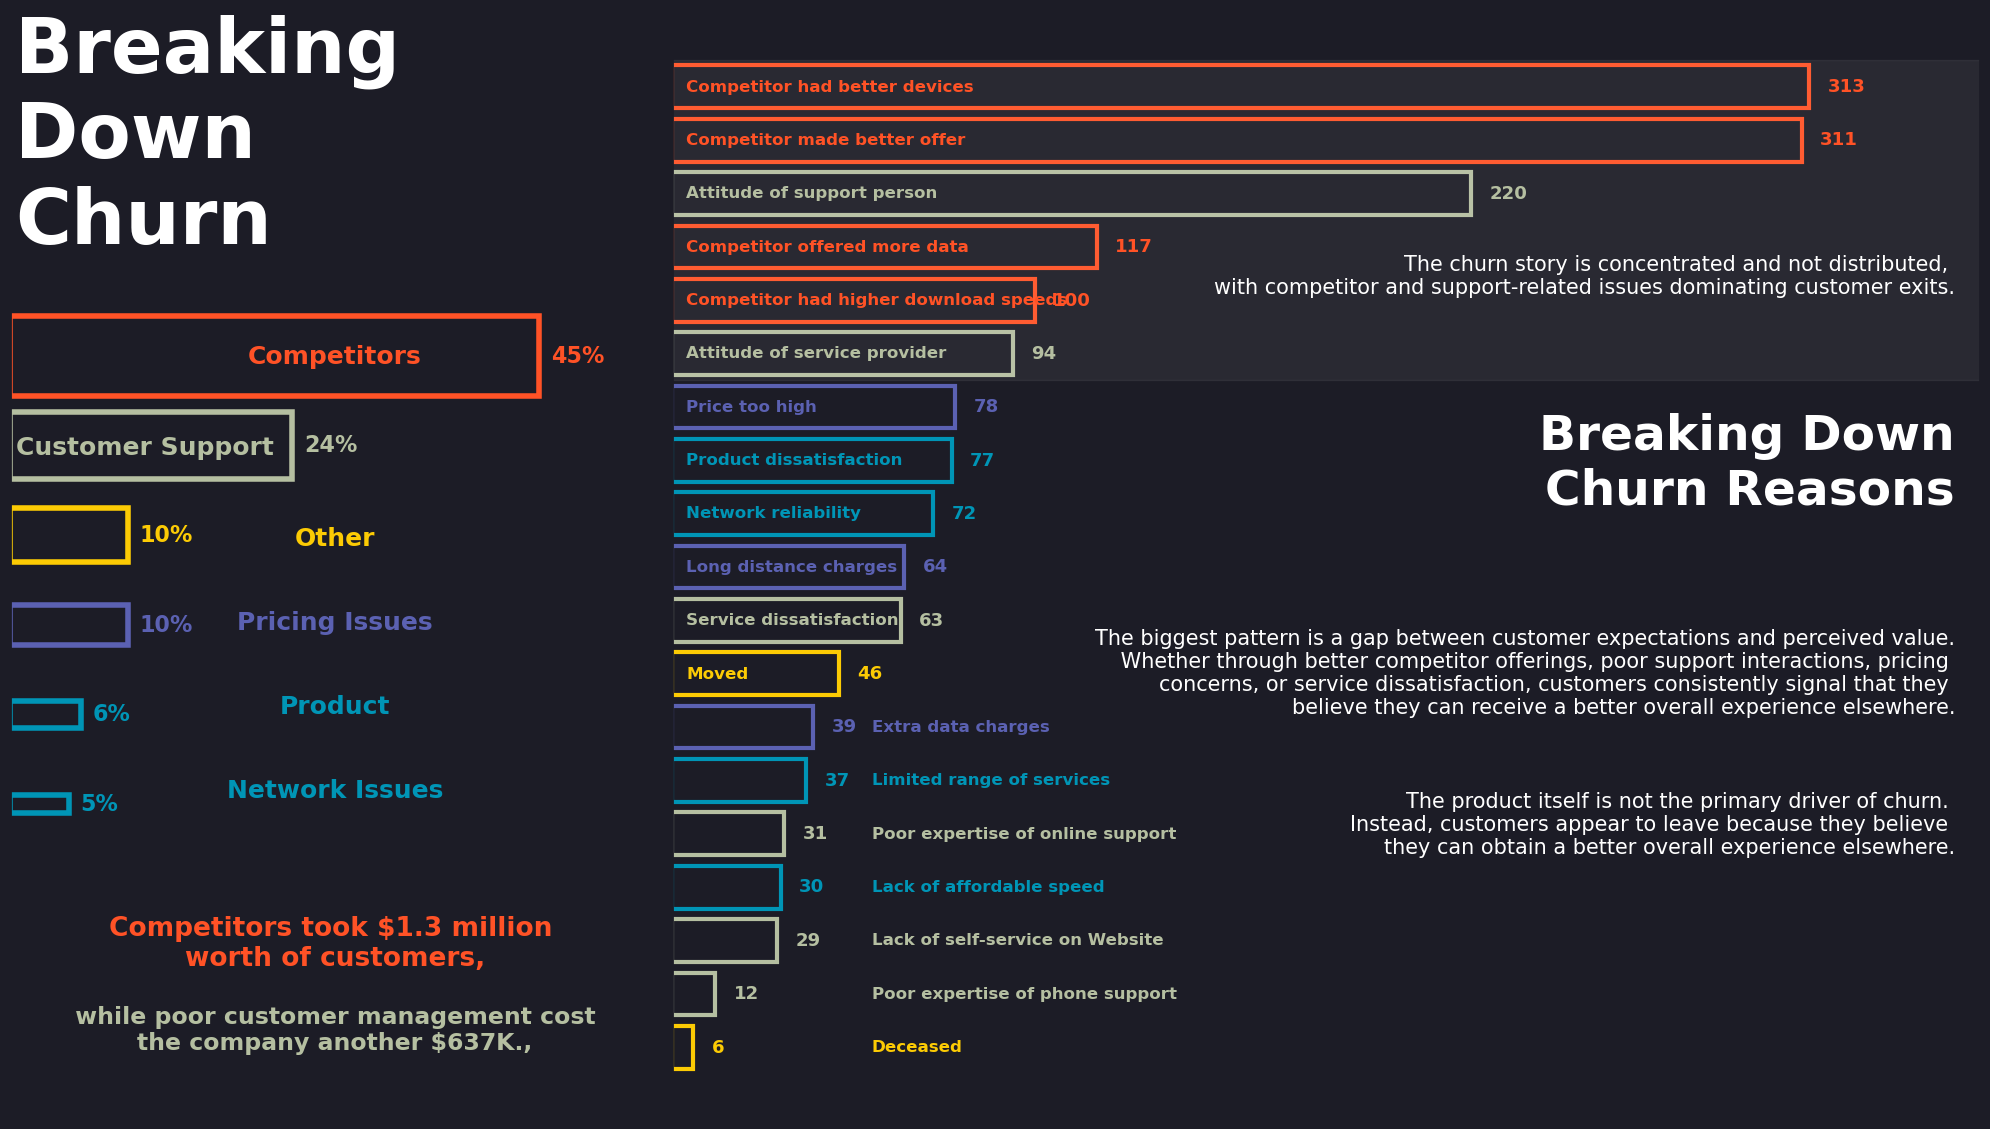

In [22]:
fig = plt.figure(figsize=(20,14),facecolor=facecolor,dpi=100)
ax1 = plt.subplot2grid((4,3),(0,0),colspan=1)
ax2 = plt.subplot2grid((4,3),(1,0),colspan=1,rowspan=2)
labels = ['Competitors','Customer Support','Other','Pricing','Product','Network']
values = [45,24,10,10,6,5]
colors = [all1,grey,stay,stayat,churn,churn]
heights = [0.9,0.75,0.6,0.45,0.3,0.2]

for i,(val,c,h) in enumerate(zip(values,colors,heights)):
    ax2.barh(i,val,height=h,color='none',edgecolor=c,linewidth=4)
    ax2.text(val+1,i,f'{val}%',va='center',ha='left',fontsize=16,color=c,fontweight='bold')

ax2.set_xlim(0,55)
ax2.set_xticks([])
ax2.set_yticks([])
ax2.invert_yaxis()
ax3 = plt.subplot2grid((4,3),(3,0),colspan=1)
ax4 = plt.subplot2grid((4,3),(0,1),colspan=2,rowspan=4)
categories=['Competitors','Customer Support','Other','Pricing','Product','Network']
colors=[all1,grey,stay,stayat,churn,churn]
categories=['Competitors','Customer Support','Other','Pricing','Product','Network']
colors=[all1,grey,stay,stayat,churn,churn]

reason_df=prepared.groupby(['Churn_Category','Churn Reason']).size().reset_index(name='Count')
reason_df['Color']=reason_df['Churn_Category'].map(dict(zip(categories,colors)))
reason_df=reason_df.sort_values('Count',ascending=False).reset_index(drop=True)
reason_df = reason_df[reason_df["Churn Reason"] != "Don't know"]
y=np.arange(len(reason_df))
bars=ax4.barh(y,reason_df['Count'],color='none',edgecolor=reason_df['Color'],linewidth=3)
for i,(cnt,c) in enumerate(zip(reason_df['Count'],reason_df['Color'])):
    ax4.text(cnt+5,i,f'{cnt}',va='center',ha='left',fontsize=13,color=c,fontweight='bold')
for i,(reason,c) in enumerate(zip(reason_df['Churn Reason'][:12],reason_df['Color'][:12])):
    ax4.text(4,i,reason,va='center',ha='left',fontsize=12,fontweight='bold',color=c)
for i,(reason,c) in enumerate(zip(reason_df['Churn Reason'][12:],reason_df['Color'][12:]),start=12):
    ax4.text(55,i,reason,va='center',ha='left',fontsize=12,fontweight='bold',color=c)
ax4.set_xlim(0,reason_df['Count'].max()*1.15)
ax4.set_xticks([])
ax4.set_yticks([])
ax4.invert_yaxis()
for ax in [ax1,ax2,ax3,ax4]:
    ax.set_facecolor(facecolor)
    [spine.set(color=facecolor,linewidth=2) for spine in ax.spines.values()]
for ax in [ax1,ax2,ax3,ax4]: ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Breaking \nDown \nChurn",x=0.01,y=0.8,fontsize=55,color="white",fontweight="bold",ha="left")
fig.text(0.17,0.12,"Competitors took $1.3 million \nworth of customers,",fontsize=19,fontweight="bold",color=all1,ha="center")
fig.text(0.17,0.06," while poor customer management cost \nthe company another $637K.,",fontsize=17,fontweight="bold",color=grey,ha="center")
fig.text(0.98,0.45,"Breaking Down\nChurn Reasons",fontsize=35,fontweight="bold",color="white",ha="right")
fig.text(0.98,0.3,"The biggest pattern is a gap between customer expectations and perceived value.\n Whether through better competitor offerings, poor support interactions, pricing \nconcerns, or service dissatisfaction, customers consistently signal that they \nbelieve they can receive a better overall experience elsewhere.",
         fontsize=15,fontweight="regular",color="white",ha="right")
fig.text(0.98,0.6,"The churn story is concentrated and not distributed, \nwith competitor and support-related issues dominating customer exits.",
         fontsize=15,fontweight="regular",color="white",ha="right")
fig.text(0.98,0.2,"The product itself is not the primary driver of churn. \nInstead, customers appear to leave because they believe \nthey can obtain a better overall experience elsewhere.",
         fontsize=15,fontweight="regular",color="white",ha="right")
fig.text(0.17,0.55,"Competitors",fontsize=18,fontweight="bold",color=all1,ha="center")
fig.text(0.075,0.485,"Customer Support",fontsize=18,fontweight="bold",color=grey,ha="center")
fig.text(0.17,0.42,"Other",fontsize=18,fontweight="bold",color=stay,ha="center")
fig.text(0.17,0.36,"Pricing Issues",fontsize=18,fontweight="bold",color=stayat,ha="center")
fig.text(0.17,0.3,"Product",fontsize=18,fontweight="bold",color=churn,ha="center")
fig.text(0.17,0.24,"Network Issues",fontsize=18,fontweight="bold",color=churn,ha="center")
ax4.axhspan(-0.5,5.5,color="white",alpha=0.06)
# plt.savefig("churn reasons main.png", dpi=300, bbox_inches="tight", facecolor=facecolor)
plt.tight_layout()
plt.show()

In [23]:
risk_columns = ['Contract', 'Online Security', 'Premium Tech Support', 'Paperless Billing',
                'Payment Method', 'Internet Type', 'Online Backup', 'Device Protection Plan',
                'Offer', 'Streaming Music', 'Streaming TV']
global_churn_rate = (prepared['Customer Status'] == 'Churned').mean()
total_churned = (prepared['Customer Status'] == 'Churned').sum()
lift_results = []
for col in risk_columns:
    categories = prepared[col].unique()
    for cat in categories:
        group = prepared[prepared[col] == cat]
        customer_count = len(group)
        churn_count = (group['Customer Status'] == 'Churned').sum()
        churn_rate = (group['Customer Status'] == 'Churned').mean()
        lift_pct = ((churn_rate / global_churn_rate) - 1) * 100
        contribution_pct = (churn_count / total_churned) * 100
        lift_results.append({
            'Feature': f'{col}: {cat}','Customer_Count': customer_count,'Churned_Count': churn_count,'Churn_Rate': churn_rate * 100,'Lift_Percentage': lift_pct,'Contribution_Percentage': contribution_pct })
lift_df = pd.DataFrame(lift_results).sort_values('Lift_Percentage',ascending=False).reset_index(drop=True)

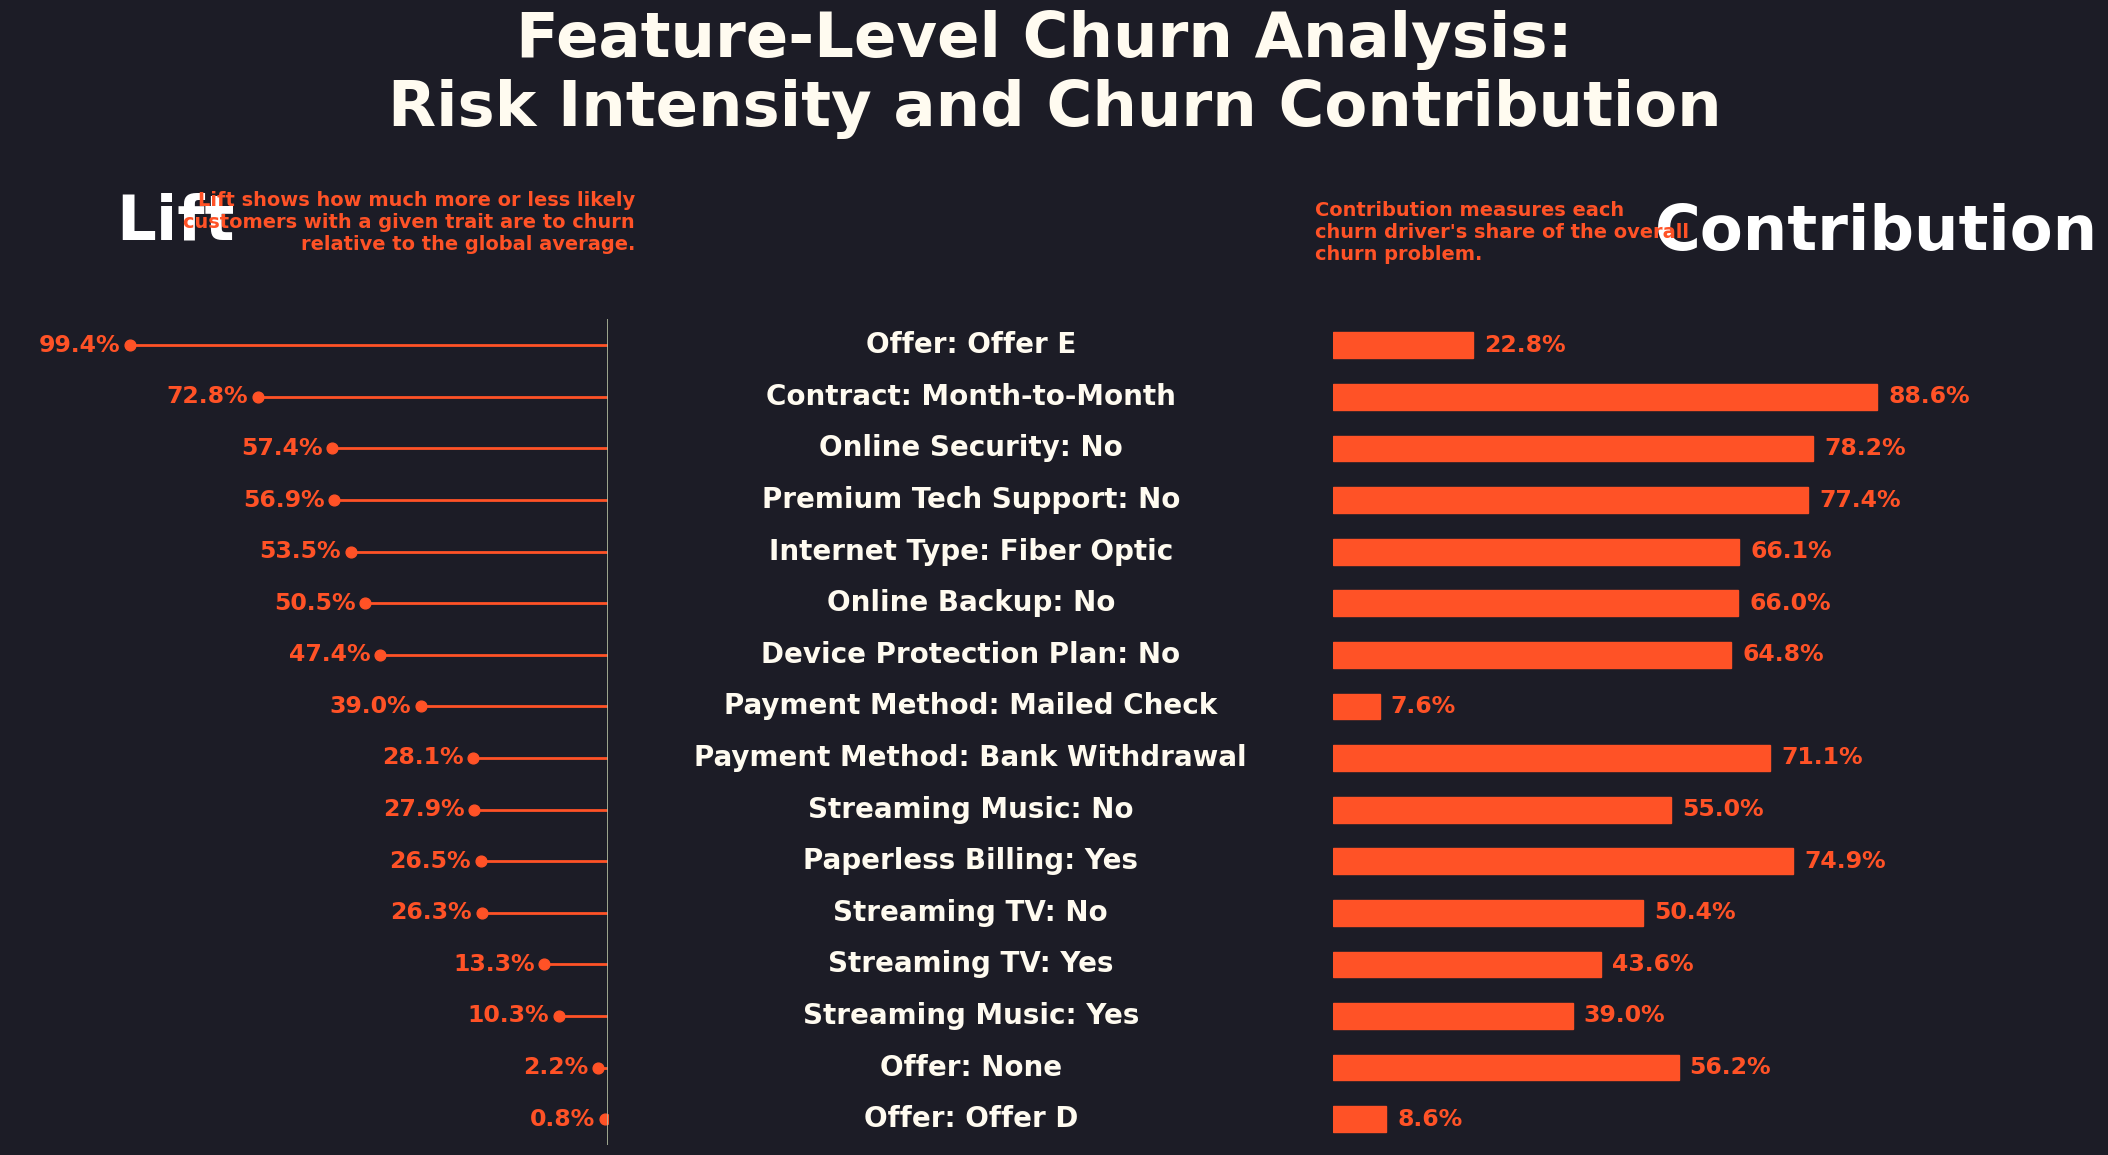

In [24]:
plot_df = lift_df.head(16).copy()
y = np.arange(len(plot_df))
fig,(ax_lift,ax_feat,ax_contrib)=plt.subplots(ncols=3,figsize=(20,10),dpi=100)
for ax in [ax_lift,ax_feat,ax_contrib]:
    ax.set_facecolor(facecolor)
fig.patch.set_facecolor(facecolor)
# ---------- LIFT ---------- #
# ---------- LIFT ---------- #
lift_max = plot_df['Lift_Percentage'].max()
ax_lift.set_xlim(lift_max*1.25,0)
ax_lift.set_ylim(len(plot_df)-0.5,-0.5)

for i,val in enumerate(plot_df['Lift_Percentage']):
    ax_lift.hlines(i,val,0,color=all1,linewidth=2)
    ax_lift.scatter(val,i,color=all1,s=60)
    ax_lift.text(val+2,i,f'{val:.1f}%',va='center',ha='right',fontsize=17,color=all1,fontweight='bold')

ax_lift.axvline(0,color=grey,linewidth=1.2)
ax_lift.set_xticks([])
ax_lift.set_yticks([])

# ---------- FEATURES ---------- #
ax_feat.set_xlim(0,1)
ax_feat.set_ylim(-0.5,len(plot_df)-0.5)
for i,feat in enumerate(plot_df['Feature']):
    ax_feat.text(0.5,i,feat,ha='center',va='center',fontsize=20,fontweight='bold',color='#fffbf0')
ax_feat.set_xticks([])
ax_feat.set_yticks([])
ax_feat.invert_yaxis()

# ---------- CONTRIBUTION ---------- #
contrib_max = plot_df['Contribution_Percentage'].max()
ax_contrib.barh(y,plot_df['Contribution_Percentage'],color=all1,edgecolor=all1,height=0.5)
ax_contrib.set_xlim(0,contrib_max*1.1)
ax_contrib.set_ylim(-0.5,len(plot_df)-0.5)
for i,val in enumerate(plot_df['Contribution_Percentage']):
    ax_contrib.text(val+contrib_max*0.02,i,f'{val:.1f}%',va='center',ha='left',fontsize=17,color=all1,fontweight='bold')
ax_contrib.set_xticks([])
ax_contrib.set_yticks([])
ax_contrib.invert_yaxis()

# ---------- CLEANUP ---------- #
for ax in [ax_lift,ax_feat,ax_contrib]:
    for spine in ax.spines.values():
        spine.set_visible(False)

# ---------- TEXT ---------- #
fig.text(0.12,0.92,'Lift',color="white",fontsize=45,fontweight='bold',ha="right")
fig.text(0.32,0.91,'Lift shows how much more or less likely\ncustomers with a given trait are to churn\nrelative to the global average.',
         color=all1,fontsize=14,fontweight='bold',ha="right")
fig.text(0.83,0.91,'Contribution',color="white",fontsize=45,fontweight='bold')
fig.text(0.66,0.9,"Contribution measures each \nchurn driver's share of the overall \nchurn problem.",color=all1,fontsize=14,fontweight='bold')
fig.suptitle('Feature-Level Churn Analysis: \nRisk Intensity and Churn Contribution',x=0.53,y=1.15,fontsize=45,color='#fffbf0',fontweight='bold')
# plt.savefig("churn drivers2.png", dpi=300, bbox_inches="tight", facecolor=facecolor)
plt.tight_layout()
plt.show()

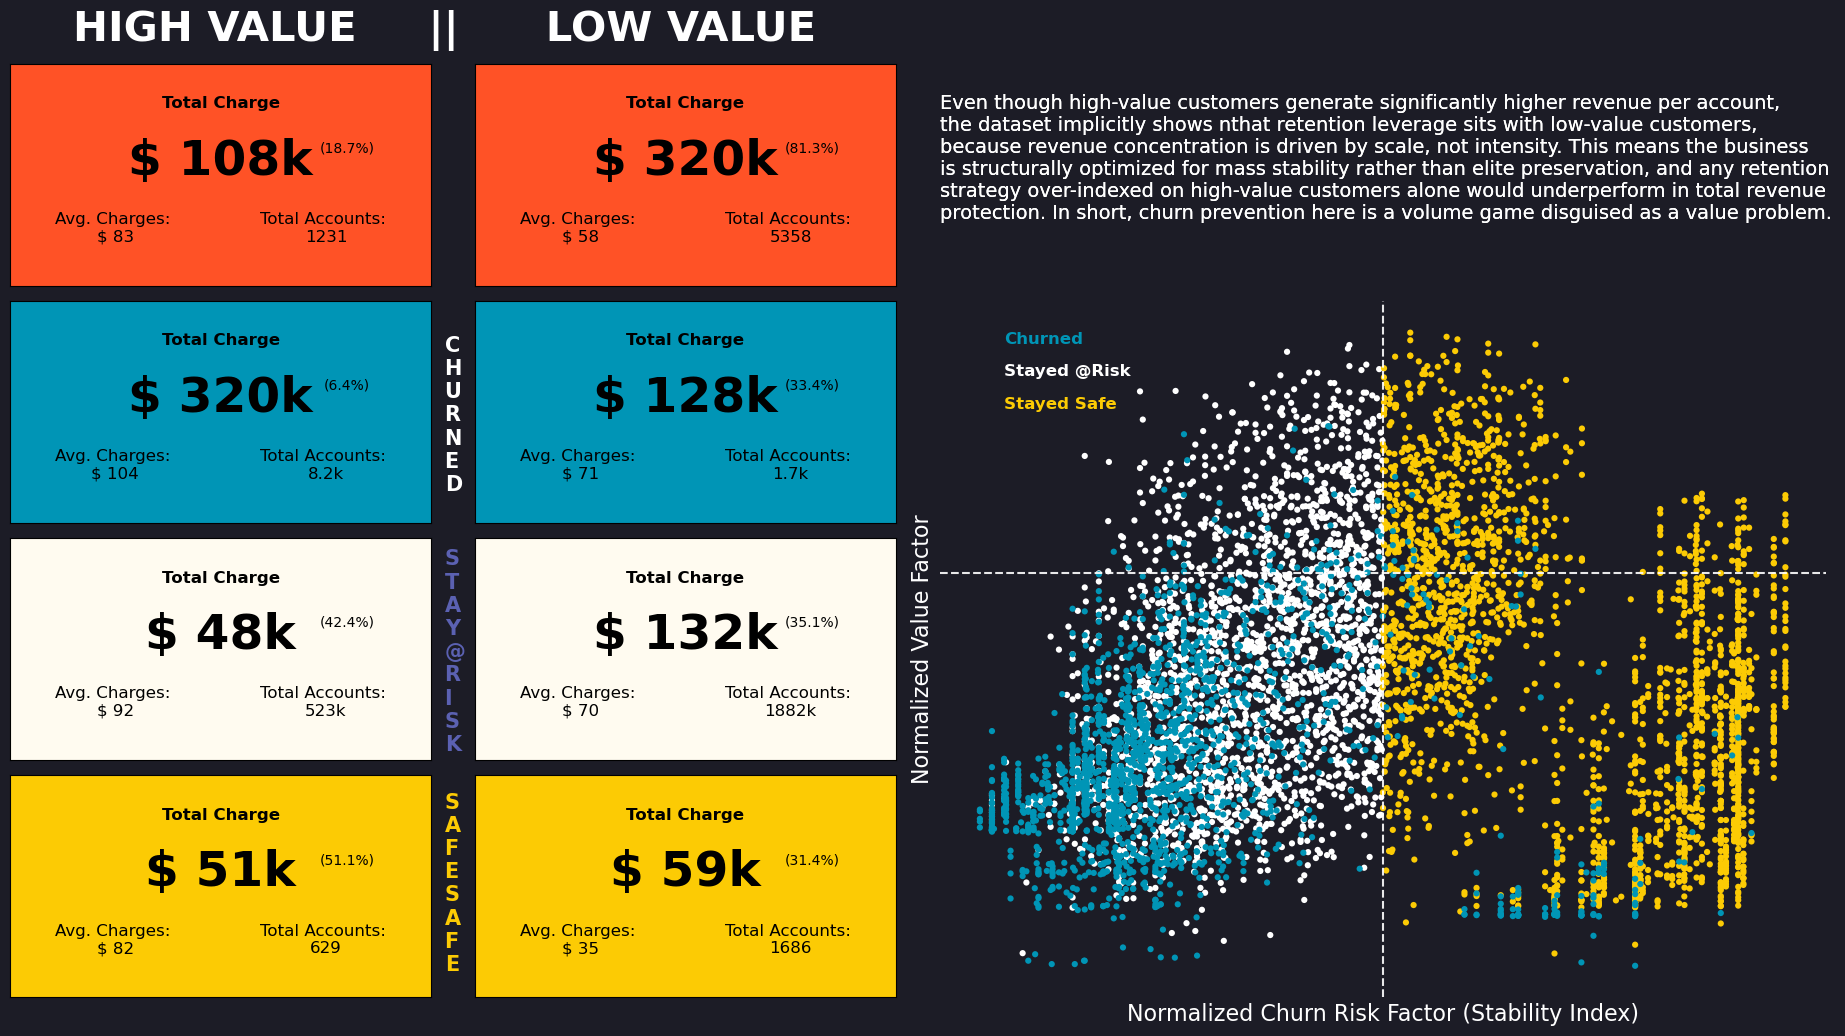

In [25]:
fig=plt.figure(figsize=(20,10),facecolor=facecolor,dpi=100)
ax1=plt.subplot2grid((4,4),(0,0))
ax1.patch.set_facecolor(all1)
ax1.text(0.5,0.8,"Total Charge",fontsize=12,ha="center",fontweight="bold",color=white)
ax1.text(0.5,0.5,"$ 108k",fontsize=35,ha="center",fontweight="bold",color=white)
ax1.text(0.25,0.2,"Avg. Charges: \n$ 83",fontsize=12,ha="center",fontweight="regular",color=white)
ax1.text(0.75,0.2,"Total Accounts: \n1231",fontsize=12,ha="center",fontweight="regular",color=white)
ax1.text(0.8,0.6,"(18.7%)",fontsize=10,ha="center",fontweight="regular",color=white)
ax2=plt.subplot2grid((4,4),(0,1))
ax2.patch.set_facecolor(all1)
ax2.text(0.5,0.8,"Total Charge",fontsize=12,ha="center",fontweight="bold",color=white)
ax2.text(0.5,0.5,"$ 320k",fontsize=35,ha="center",fontweight="bold",color=white)
ax2.text(0.25,0.2,"Avg. Charges: \n$ 58",fontsize=12,ha="center",fontweight="regular",color=white)
ax2.text(0.75,0.2,"Total Accounts: \n5358",fontsize=12,ha="center",fontweight="regular",color=white)
ax2.text(0.8,0.6,"(81.3%)",fontsize=10,ha="center",fontweight="regular",color=white)
ax3=plt.subplot2grid((4,4),(1,0))
ax3.patch.set_facecolor(churn)
ax3.text(0.5,0.8,"Total Charge",fontsize=12,ha="center",fontweight="bold",color=white)
ax3.text(0.5,0.5,"$ 320k",fontsize=35,ha="center",fontweight="bold",color=white)
ax3.text(0.25,0.2,"Avg. Charges: \n$ 104",fontsize=12,ha="center",fontweight="regular",color=white)
ax3.text(0.75,0.2,"Total Accounts: \n8.2k",fontsize=12,ha="center",fontweight="regular",color=white)
ax3.text(0.8,0.6,"(6.4%)",fontsize=10,ha="center",fontweight="regular",color=white)
ax4=plt.subplot2grid((4,4),(1,1))
ax4.patch.set_facecolor(churn)
ax4.text(0.5,0.8,"Total Charge",fontsize=12,ha="center",fontweight="bold",color=white)
ax4.text(0.5,0.5,"$ 128k",fontsize=35,ha="center",fontweight="bold",color=white)
ax4.text(0.25,0.2,"Avg. Charges: \n$ 71",fontsize=12,ha="center",fontweight="regular",color=white)
ax4.text(0.75,0.2,"Total Accounts: \n1.7k",fontsize=12,ha="center",fontweight="regular",color=white)
ax4.text(0.8,0.6,"(33.4%)",fontsize=10,ha="center",fontweight="regular",color=white)
ax5=plt.subplot2grid((4,4),(2,0))
white ="#000000"
ax5.patch.set_facecolor("#fffbf0")
ax5.text(0.5,0.8,"Total Charge",fontsize=12,ha="center",fontweight="bold",color=white)
ax5.text(0.5,0.5,"$ 48k",fontsize=35,ha="center",fontweight="bold",color=white)
ax5.text(0.25,0.2,"Avg. Charges: \n$ 92",fontsize=12,ha="center",fontweight="regular",color=white)
ax5.text(0.75,0.2,"Total Accounts: \n523k",fontsize=12,ha="center",fontweight="regular",color=white)
ax5.text(0.8,0.6,"(42.4%)",fontsize=10,ha="center",fontweight="regular",color=white)
ax6=plt.subplot2grid((4,4),(2,1))
ax6.patch.set_facecolor("#fffbf0")
white ="#000000"
ax6.text(0.5,0.8,"Total Charge",fontsize=12,ha="center",fontweight="bold",color=white)
ax6.text(0.5,0.5,"$ 132k",fontsize=35,ha="center",fontweight="bold",color=white)
ax6.text(0.25,0.2,"Avg. Charges: \n$ 70",fontsize=12,ha="center",fontweight="regular",color=white)
ax6.text(0.75,0.2,"Total Accounts: \n1882k",fontsize=12,ha="center",fontweight="regular",color=white)
ax6.text(0.8,0.6,"(35.1%)",fontsize=10,ha="center",fontweight="regular",color=white)
ax7=plt.subplot2grid((4,4),(3,0))
ax7.patch.set_facecolor(stay)
# white ="#ffffff"
ax7.text(0.5,0.8,"Total Charge",fontsize=12,ha="center",fontweight="bold",color=white)
ax7.text(0.5,0.5,"$ 51k",fontsize=35,ha="center",fontweight="bold",color=white)
ax7.text(0.25,0.2,"Avg. Charges: \n$ 82",fontsize=12,ha="center",fontweight="regular",color=white)
ax7.text(0.75,0.2,"Total Accounts: \n629",fontsize=12,ha="center",fontweight="regular",color=white)
ax7.text(0.8,0.6,"(51.1%)",fontsize=10,ha="center",fontweight="regular",color=white)
ax8=plt.subplot2grid((4,4),(3,1))
ax8.patch.set_facecolor(stay)
ax8.text(0.5,0.8,"Total Charge",fontsize=12,ha="center",fontweight="bold",color=white)
ax8.text(0.5,0.5,"$ 59k",fontsize=35,ha="center",fontweight="bold",color=white)
ax8.text(0.25,0.2,"Avg. Charges: \n$ 35",fontsize=12,ha="center",fontweight="regular",color=white)
ax8.text(0.75,0.2,"Total Accounts: \n1686",fontsize=12,ha="center",fontweight="regular",color=white)
ax8.text(0.8,0.6,"(31.4%)",fontsize=10,ha="center",fontweight="regular",color=white)
ax9=plt.subplot2grid((4,4),(0,2),colspan=2)
ax9.patch.set_facecolor(facecolor)
for spine in ax9.spines.values():
    spine.set_visible(False)
ax9.text(0,0.3,"Even though high-value customers generate significantly higher revenue per account, \nthe dataset implicitly shows nthat retention leverage sits with low-value customers, \nbecause revenue concentration is driven by scale, not intensity. This means the business \nis structurally optimized for mass stability rather than elite preservation, and any retention \nstrategy over-indexed on high-value customers alone would underperform in total revenue \nprotection. In short, churn prevention here is a volume game disguised as a value problem.",
         color="white",fontsize=14,fontweight="regular")
ax10=plt.subplot2grid((4,4),(1,2),rowspan=3,colspan=2)
ax10.patch.set_facecolor(facecolor)
color_map = {'Stayed @ Risk': "white", 'Stayed Safe': stay, 'Churned': churn}
alpha_map = {'Stayed @ Risk': 1.0, 'Stayed Safe': 1.0, 'Churned': 1.0}
for segment, color in color_map.items():
    subset = master_df[master_df['Strategic_Segment'] == segment]
    ax10.scatter(subset['NCRF'], subset['NVF'], label=segment, color=color, alpha=alpha_map[segment], edgecolors='none', s=20)
ax10.axvline(0.5, color='white', linestyle='--', alpha=0.9);ax10.axhline(0.6, color='white', linestyle='--', alpha=0.9);ax10.yaxis.label.set_color('white');ax10.yaxis.label.set_size(16)
ax10.set_xlabel('Normalized Churn Risk Factor (Stability Index)');ax10.set_ylabel('Normalized Value Factor');ax10.set_title("", color="white", fontsize=15)
for spine in ax10.spines.values():
    spine.set_visible(False)
ax10.tick_params(axis='x', colors='white');ax10.xaxis.label.set_color('white');ax10.xaxis.label.set_size(16);ax10.tick_params(axis='y', colors='white')
for ax in fig.axes:
    ax.set_xticks([]);ax.set_yticks([])
fig.text(0.225,0.55,"C \nH \nU \nR \nN \nE \nD",color="white",fontsize=15,fontweight="bold")
fig.text(0.225,0.29,"S \nT \nA \nY \n@ \nR \nI \nS \nK",color=stayat,fontsize=15,fontweight="bold")
fig.text(0.225,0.07,"S \nA \nF \nE \nS \nA \nF \nE",color=stay,fontsize=15,fontweight="bold")
fig.text(0.11,1,"HIGH VALUE",color="white",fontsize=30,fontweight="bold",ha="center")
fig.text(0.31,1," ||      LOW VALUE",color="white",fontsize=30,fontweight="bold",ha="center")
ax9.text(0,0.3,"Even though high-value customers generate significantly higher revenue per account, \nthe dataset implicitly shows nthat retention leverage sits with low-value customers, \nbecause revenue concentration is driven by scale, not intensity. This means the business \nis structurally optimized for mass stability rather than elite preservation, and any retention \nstrategy over-indexed on high-value customers alone would underperform in total revenue \nprotection. In short, churn prevention here is a volume game disguised as a value problem.",
         color="white",fontsize=14,fontweight="regular")
ax10.text(0.03,0.95,"Churned",color=churn,fontsize=12,fontweight="bold")
ax10.text(0.03,0.9,"Stayed @Risk",color="white",fontsize=12,fontweight="bold")
ax10.text(0.03,0.85,"Stayed Safe",color=stay,fontsize=12,fontweight="bold")
plt.tight_layout()
plt.show()


In [26]:
connectivity_yes = ['Phone Service']
connectivity_no = ['Internet Service']
service_cols = ['Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music']
fortress_mask = (prepared['Internet Service'] == 'No') & (prepared['Phone Service'] == 'Yes') & (prepared['Customer Status'] == 'Stayed')
fortress_cluster = prepared[fortress_mask]
cluster_size = len(fortress_cluster)

print(f"Total Points in Cluster: {cluster_size}\n")

# 1. Phone Service Check (Target: 'Yes')
for col in connectivity_yes:
    cluster_count = (fortress_cluster[col] == 'Yes').sum()
    total_in_company = (prepared[col] == 'Yes').sum()
    capture_rate = (cluster_count / total_in_company) * 100
    print(f"{col}: {cluster_count} points | {capture_rate:.1f}% Capture (Target: 'Yes')")

# 2. Internet Service Check (Target: 'No')
for col in connectivity_no:
    cluster_count = (fortress_cluster[col] == 'No').sum()
    total_in_company = (prepared[col] == 'No').sum()
    capture_rate = (cluster_count / total_in_company) * 100
    print(f"{col}: {cluster_count} points | {capture_rate:.1f}% Capture (Target: 'No')")

# 3. Digital Service Check (Target: 'None')
for col in service_cols:
    cluster_count = (fortress_cluster[col] == 'None').sum()
    total_in_company = (prepared[col] == 'None').sum()
    capture_rate = (cluster_count / total_in_company) * 100
    print(f"{col}: {cluster_count} points | {capture_rate:.1f}% Capture (Target: 'None')")

Total Points in Cluster: 1231

Phone Service: 1231 points | 19.4% Capture (Target: 'Yes')
Internet Service: 1231 points | 80.7% Capture (Target: 'No')
Online Security: 1231 points | 80.7% Capture (Target: 'None')
Online Backup: 1231 points | 80.7% Capture (Target: 'None')
Device Protection Plan: 1231 points | 80.7% Capture (Target: 'None')
Premium Tech Support: 1231 points | 80.7% Capture (Target: 'None')
Streaming TV: 1231 points | 80.7% Capture (Target: 'None')
Streaming Movies: 1231 points | 80.7% Capture (Target: 'None')
Streaming Music: 1231 points | 80.7% Capture (Target: 'None')


In [27]:
# Calculating the percentage of 'Stayed' customers within the identified segment
total_segment_customers = (prepared['Internet Service'] == 'No') & (prepared['Phone Service'] == 'Yes')
stayed_count = ((prepared['Customer Status'] == 'Stayed') & total_segment_customers).sum()
total_count = total_segment_customers.sum()
stayed_percentage = (stayed_count / total_count) * 100
print(f"Total Customers in Segment: {total_count}")
print(f"Customers who Stayed: {stayed_count}")
print(f"Percentage of People who Stayed: {stayed_percentage:.2f}%")

Total Customers in Segment: 1526
Customers who Stayed: 1231
Percentage of People who Stayed: 80.67%


In [28]:
# Filtering for the 1,231 customers (Non-Digital Stayed Segment)
fortress_mask = (prepared['Internet Service'] == 'No') & \
                (prepared['Phone Service'] == 'Yes') & \
                (prepared['Customer Status'] == 'Stayed')

# Calculate Revenue Metrics
segment_revenue = prepared[fortress_mask]['Total Revenue'].sum()
total_company_revenue = prepared['Total Revenue'].sum()
revenue_percentage = (segment_revenue / total_company_revenue) * 100

print(f"Total Revenue held by Segment: ${segment_revenue:,.2f}")
print(f"Percentage of Total Company Revenue: {revenue_percentage:.2f}%")

Total Revenue held by Segment: $2,129,501.17
Percentage of Total Company Revenue: 9.96%


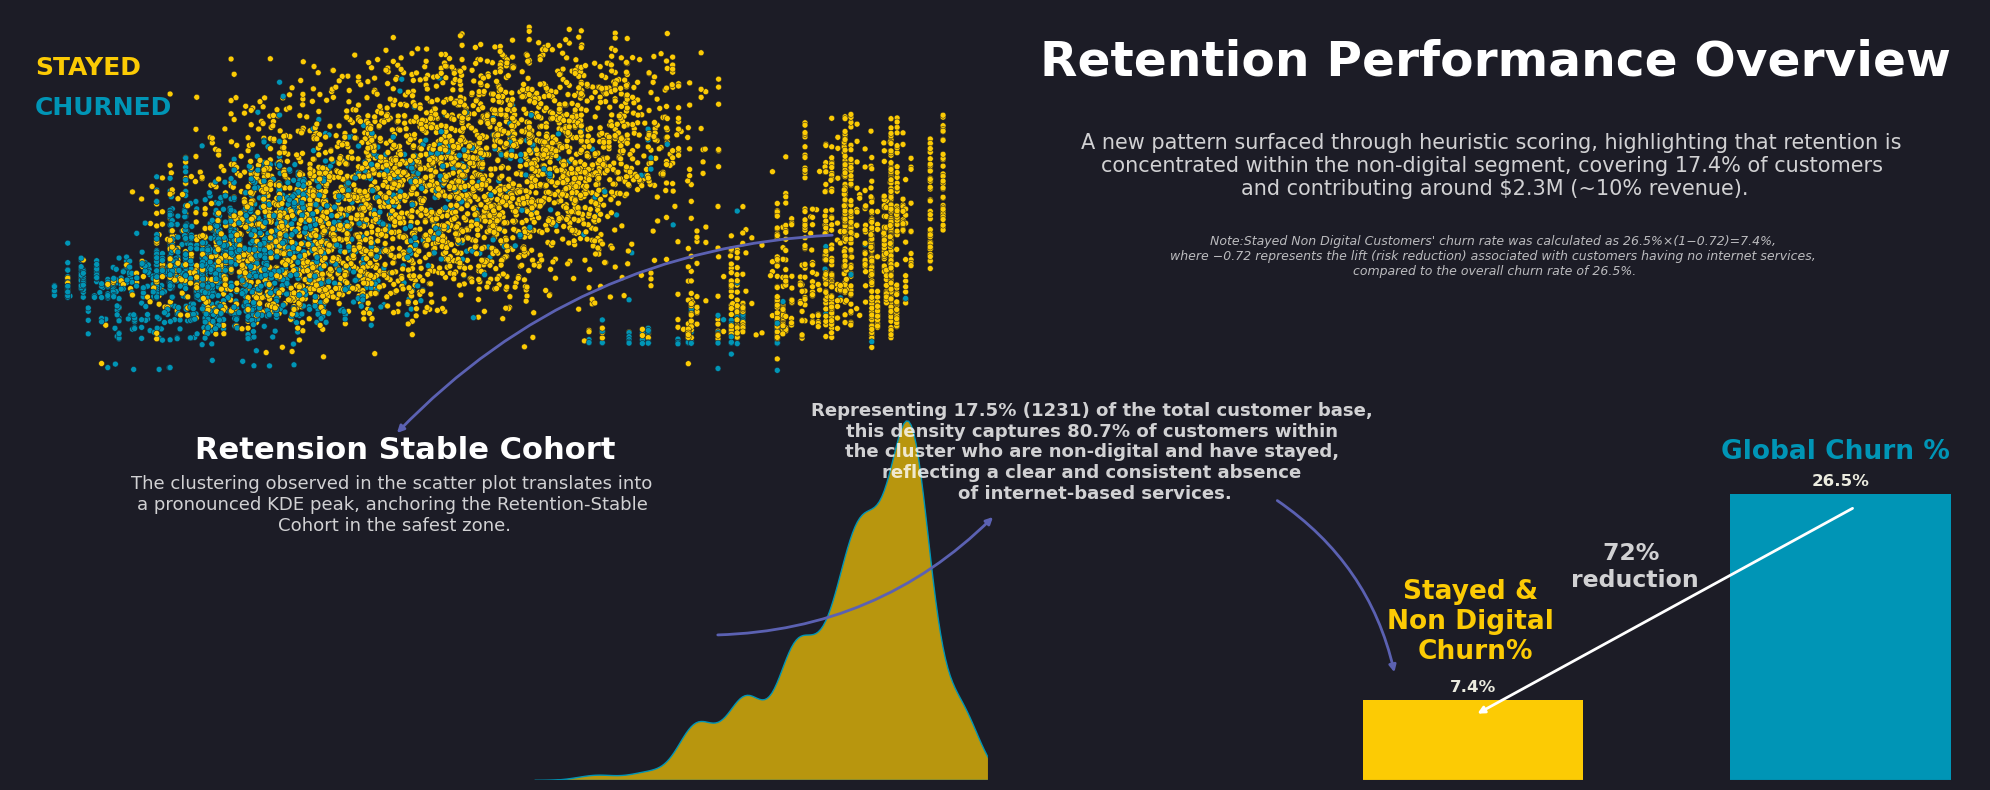

In [29]:
fig = plt.figure(figsize=(20, 8), facecolor=facecolor, dpi=100)
fig.patch.set_facecolor(facecolor)
ax1 = plt.subplot2grid((2, 6), (0, 0),colspan=3)
ax2 = plt.subplot2grid((2, 6), (0, 3),colspan=3)
ax3 = plt.subplot2grid((2, 6), (1, 0),colspan=3)
ax4 = plt.subplot2grid((2, 6), (1, 3),colspan=1)
ax5 = plt.subplot2grid((2, 6), (1, 4),colspan=2)
ax1.set_facecolor(facecolor); ax2.set_facecolor(facecolor); ax3.set_facecolor(facecolor); ax4.set_facecolor(facecolor); ax5.set_facecolor(facecolor)
for ax in [ax1, ax2, ax3, ax4,ax5]:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color(facecolor)
# ax1
sns.scatterplot(x=prepared[prepared["Customer Status"].isin(["Churned","Stayed"])]["NCRF"], y=prepared[prepared["Customer Status"].isin(["Churned","Stayed"])]["NVF"], hue=prepared[prepared["Customer Status"].isin(["Churned","Stayed"])]["Customer Status"], palette={"Stayed": stay, "Churned": churn}, edgecolor=facecolor, s=18, ax=ax1)
ax1.legend_.remove()
# ax3
sns.kdeplot(prepared[fortress_mask]['NCRF'], ax=ax3, color=stay, fill=True, alpha=0.7, label='Retention Fortress (Non-Digital)', edgecolor=churn)
ax3.set_xlim(0.0, 1.02)
labels = ['Market Average', 'Retention Fortress']
churn_rates = [7.4,26.5] 
colors = [stay,churn]
bars = ax5.bar(labels, churn_rates, color=colors, width=0.6)
for bar in bars:
    h = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., h + 0.5, f'{h}%', ha='center', va='bottom', fontsize=12, fontweight='bold', color="#ebebdf")
x = 0.5
y1, y2 = 7.4, 26.5
ax5.set_ylim(0, 35)
draw_arrow(fig,(0.42,0.7),(0.2,0.45),stayat,0.2)
draw_arrow(fig,(0.36,0.2),(0.5,0.35),stayat,0.2)
fig.text(0.02,0.9,"STAYED",fontsize=18,fontweight="bold",color=stay)
fig.text(0.02,0.85,"CHURNED",fontsize=18,fontweight="bold",color=churn)
for ax in [ax1, ax2, ax3, ax4,ax5]: ax.set_ylabel(""); ax.set_xlabel("")
for ax in [ax1, ax2,ax3,  ax4, ax5]: ax.set_xticks([]); ax.set_yticks([])
fig.text(0.1,0.42,"Retension Stable Cohort",color="#ffffff",fontsize=22,fontweight="bold")
fig.text(0.2,0.33,"The clustering observed in the scatter plot translates into \na pronounced KDE peak, anchoring the Retention-Stable \nCohort in the safest zone.",
         color="#ffffff",fontsize=13,fontweight="regular",alpha=0.8,ha="center")
fig.text(0.55,0.37,"Representing 17.5% (1231) of the total customer base, \nthis density captures 80.7% of customers within \nthe cluster who are non-digital and have stayed, \nreflecting a clear and consistent absence \nof internet-based services.",
         color="#ffffff",fontsize=13,fontweight="semibold",alpha=0.8,ha="center")
fig.text(0.82,0.26,"72% \nreduction",color="#ffffff",fontsize=17,fontweight="semibold",alpha=0.8,ha="center")
fig.text(0.92,0.42,"Global Churn %",color=churn,fontsize=19,fontweight="semibold",ha="center")
fig.text(0.74,0.17,"Stayed & \nNon Digital \nChurn%",color=stay,fontsize=19,fontweight="semibold",ha="center")
fig.text(0.75,0.9,"Retention Performance Overview",color="#ffffff",fontsize=35,fontweight="bold",ha="center")
fig.text(0.75,0.75,"A new pattern surfaced through heuristic scoring, highlighting that retention is \nconcentrated within the non-digital segment, covering 17.4% of customers \nand contributing around $2.3M (~10% revenue).",
         color="#ffffff",fontsize=15,fontweight="regular",ha="center",alpha=0.8)
fig.text(0.75,0.65,"Note:Stayed Non Digital Customers' churn rate was calculated as 26.5%×(1−0.72)=7.4%, \nwhere −0.72 represents the lift (risk reduction) associated with customers having no internet services, \ncompared to the overall churn rate of 26.5%.",
         color="#ffffff",fontsize=9,fontweight="regular",ha="center",alpha=0.7,fontstyle="italic")
draw_arrow(fig,(0.64,0.37),(0.7,0.15),stayat,-0.2)
draw_arrow(fig,(0.93,0.36),(0.74,0.1),"white",0)
# plt.savefig("ghost dashboard1.png", dpi=300, bbox_inches="tight", facecolor=facecolor)
plt.tight_layout()
plt.show()

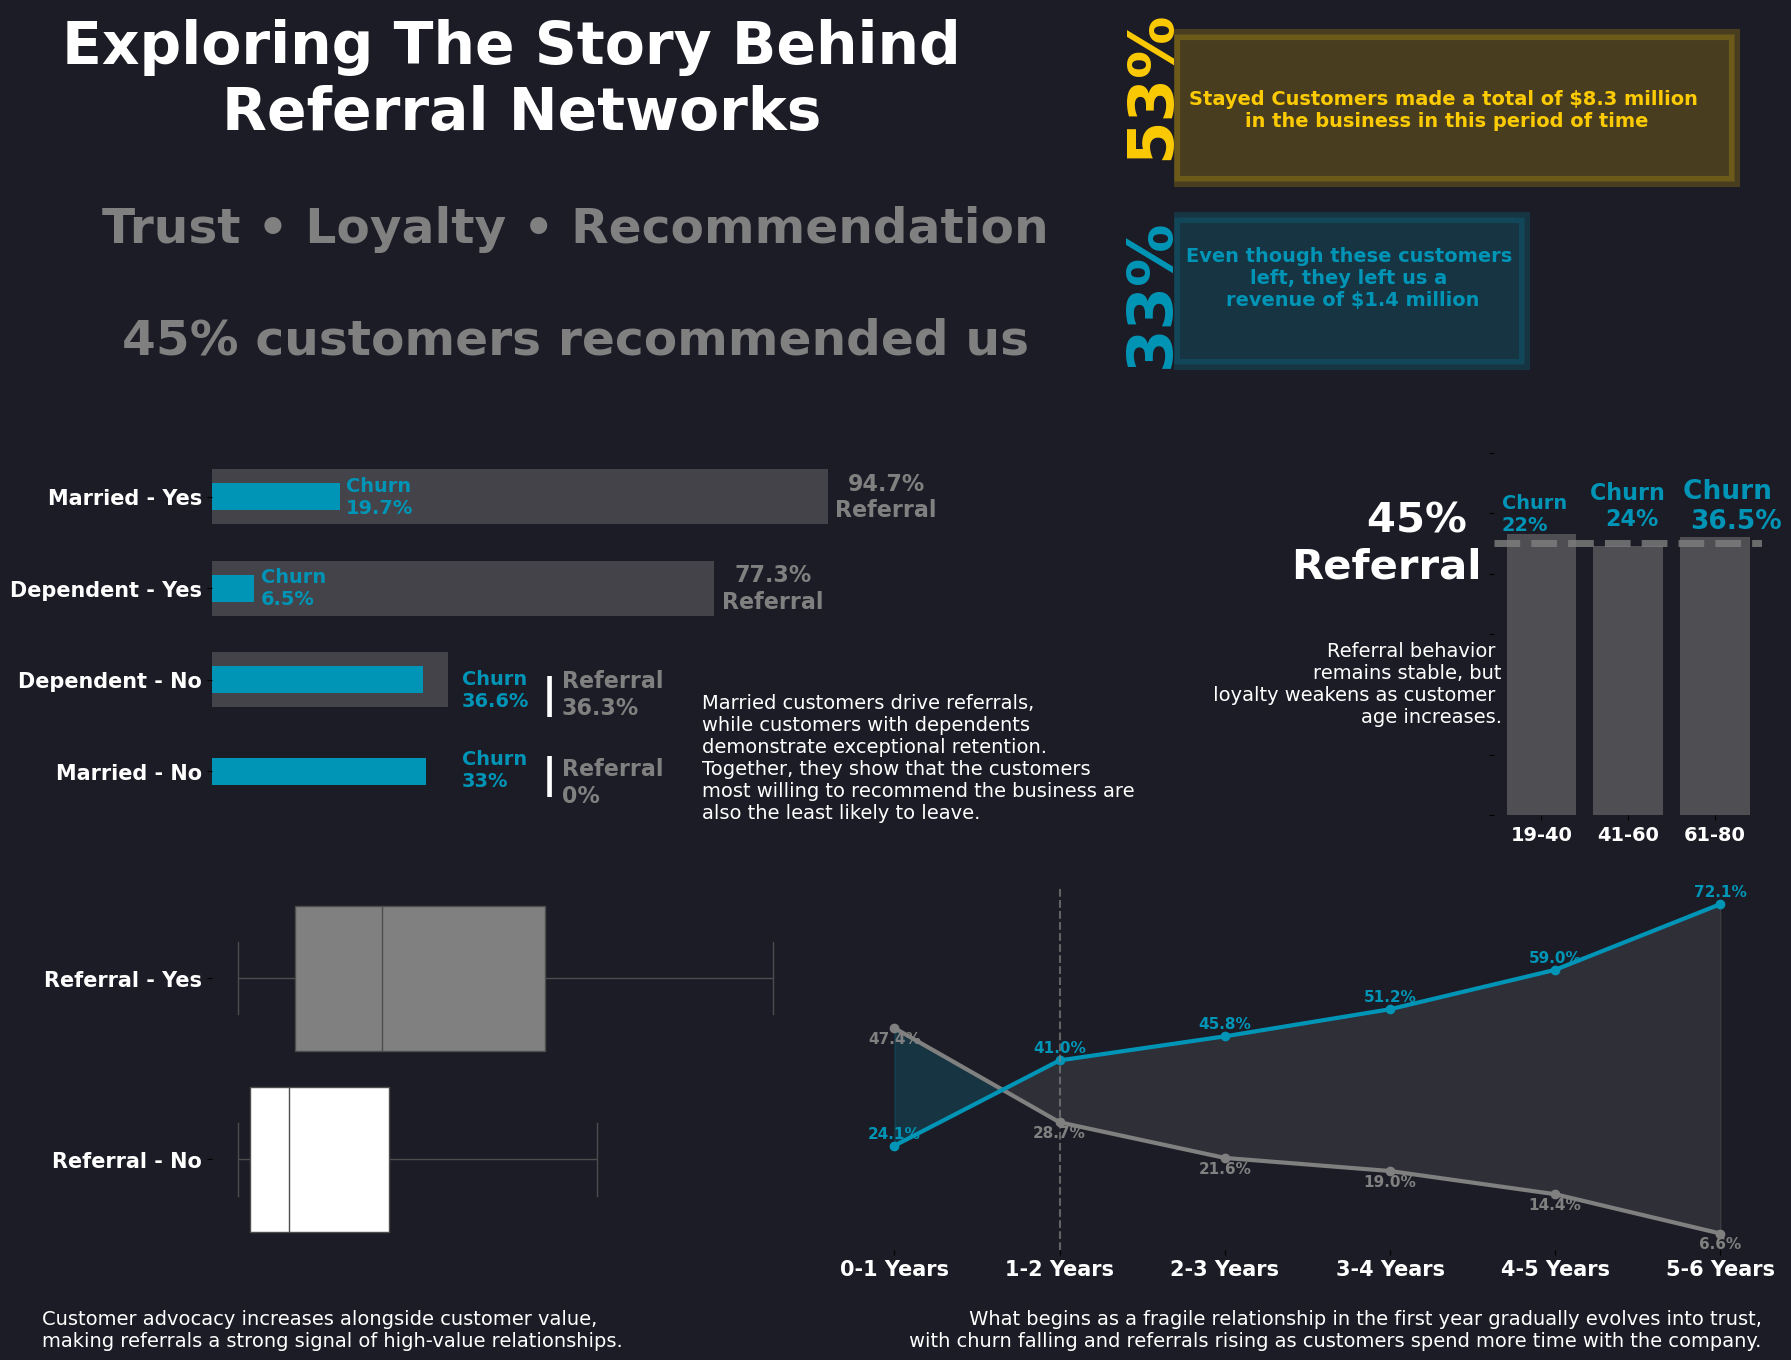

In [33]:
fig = plt.figure(figsize=(20, 16), facecolor=facecolor, dpi=100)
# the empty cell
ax1 = plt.subplot2grid((3, 5), (0, 0), colspan=3)
# the barplot of customer status
ax2 = plt.subplot2grid((3, 5), (0, 3), colspan=2)
referral_pct = ((prepared[prepared["Referral Flag"] == "Yes"].groupby("Customer Status").size() / prepared.groupby("Customer Status").size()) * 100).reset_index(name="Referral_Pct")
referral_pct = referral_pct[referral_pct["Customer Status"] != "Joined"]
colors = [stay if x == "Stayed" else churn for x in referral_pct["Customer Status"]]
bars = ax2.barh(referral_pct["Customer Status"], referral_pct["Referral_Pct"],edgecolor=colors, color=colors,alpha=0.2, linewidth=8)
# for bar, val, c in zip(bars, referral_pct["Referral_Pct"], colors):
#     ax2.text(val + 1, bar.get_y() + bar.get_height()/2,f"{val:.1f}%", va='center', color=c, fontsize=35, fontweight='bold')
#     # ax2.text(val + 1, bar.get_y() + bar.get_height()/2,f"{val:.1f}%", va='center', color=c, fontsize=30, fontweight='bold')
ax2.set_xticks([]);ax2.set_yticks([])
# the married barplot 
ax3 = plt.subplot2grid((3, 5), (1, 0),colspan=3)
categories = [("Married", "Yes", "Married - Yes"),("Dependent Flag", "Yes", "Dependent - Yes"),("Dependent Flag", "No", "Dependent - No"),("Married", "No", "Married - No"),  ]
labels = []
referral_pct = []
churn_pct = []
totals = []
for col, val, label in categories:
    subset = prepared[prepared[col] == val]
    labels.append(label)
    totals.append(len(subset))
    referral_pct.append((subset["Referral Flag"] == "Yes").mean() * 100)
    churn_pct.append((subset["Customer Status"] == "Churned").mean() * 100)
y = np.arange(len(labels))
ax3.barh(y, referral_pct, height=0.6, color="grey", alpha=0.4, label="Referral")
ax3.barh(y, churn_pct, height=0.3, color=churn, label="Churn")
ax3.set_yticks(y)
ax3.set_yticklabels(labels, fontsize=15, color="white", fontweight="bold")
for i, (ref, churn_rate) in enumerate(zip(referral_pct[:2], churn_pct[:2])):
    ax3.text(ref + 9, i, f"{ref:.1f}%\nReferral", color="grey", fontsize=16, fontweight="bold", ha="center", va="center")
    ax3.text(churn_rate + 1, i, f"Churn \n{churn_rate:.1f}%", color=churn, fontsize=14, fontweight="bold", va="center")
ax3.set_xticks([]);ax3.set_xlim(0, max(referral_pct) + 45);ax3.invert_yaxis()
for spine in ax3.spines.values():
    spine.set_visible(False)
# the age group
ax5 = plt.subplot2grid((3, 5), (1, 4),colspan=1)
ax5.patch.set_facecolor(facecolor)
ref_pct = ((prepared[prepared["Referral Flag"] == "Yes"].groupby("Age Group").size()
            / prepared.groupby("Age Group").size()) * 100).reindex(["19-40", "41-60", "61-80"])
x = np.arange(len(ref_pct))
bars = ax5.bar(x, ref_pct, color="grey", alpha=0.5)
ax5.set_xticks(x);ax5.set_xticklabels(ref_pct.index, fontsize=14, color="white", fontweight="bold");ax5.set_yticks(np.arange(0, 61, 10));ax5.set_yticklabels(np.arange(0, 61, 10), fontsize=12,color=facecolor)
ax5.axhline(y=45, color="grey", linestyle="--", linewidth=5, alpha=0.8)
# the kde plot of NVF
ax6 = plt.subplot2grid((3, 5), (2, 0), colspan=2)
sns.boxplot(data=prepared, y="Referral Flag", x="Total Charges",order=["Yes", "No"],palette={"Yes": "grey", "No": "white"},showfliers=False,ax=ax6)
ax6.set_xlabel("");ax6.set_ylabel("");ax6.set_xticks([]);ax6.set_yticklabels(["Referral - Yes", "Referral - No"],fontsize=15, color="white", fontweight="bold")
# the line plot of churned vs referral
ax7 = plt.subplot2grid((3, 5), (2, 2), colspan=3)
tenure_order = ['0-1 Years', '1-2 Years', '2-3 Years', '3-4 Years', '4-5 Years', '5-6 Years']
tenure_cats = tenure_order
churn_rates = (prepared[prepared["Customer Status"] == "Churned"].groupby("Tenure in Years").size() / prepared.groupby("Tenure in Years").size() * 100).reindex(tenure_order)
referral_rates = (prepared[prepared["Referral Flag"] == "Yes"].groupby("Tenure in Years").size() / prepared.groupby("Tenure in Years").size() * 100).reindex(tenure_order)
ax7.plot(tenure_cats, churn_rates, color="grey", linewidth=3, marker="o", label="Churn Rate (%)")
ax7.plot(tenure_cats, referral_rates, color=churn, linewidth=3, marker="o", label="Referral Rate (%)")
ax7.fill_between(tenure_cats, churn_rates, referral_rates, where=np.array(referral_rates) >= np.array(churn_rates), interpolate=True, color="grey", alpha=0.2)
ax7.fill_between(tenure_cats, churn_rates, referral_rates,where=np.array(churn_rates) > np.array(referral_rates),interpolate=True, color=churn, alpha=0.2)
for x, y in zip(tenure_cats, churn_rates):
    ax7.text(x, y - 3, f"{y:.1f}%", ha="center", fontsize=11, color="grey", fontweight="bold")
for x, y in zip(tenure_cats, referral_rates):
    ax7.text(x, y + 1.5, f"{y:.1f}%", ha="center", fontsize=11, color=churn, fontweight="bold")
ax7.axvline(x='1-2 Years', linestyle='--', color='grey', alpha=0.7)
ax7.set_xticks(range(len(tenure_cats)));ax7.set_xticklabels(tenure_cats, fontsize=15, color="white",fontweight="bold")
axes = [ax1, ax2, ax3, ax5, ax6, ax7]
for ax in axes:
    ax.set_facecolor(facecolor)
    for spine in ax.spines.values():
        spine.set_visible(False)
for ax in [ax1, ax2]:
    ax.set_xticks([])
    ax.set_yticks([])
for ax in [ ax7]:
    ax.set_yticks([])
fig.suptitle("Exploring The Story Behind \nReferral Networks",fontsize=42,x=0.28,y=0.88,color="white",fontweight="bold")
# ax4 plot texts
fig.text(0.25,0.45,"Churn \n36.6%",color=churn,fontsize=14,fontweight="bold")
fig.text(0.29,0.45,"|",color="white",fontsize=30,fontweight="bold")
fig.text(0.3,0.445,"Referral \n36.3%",color="grey",fontsize=16,fontweight="bold")
fig.text(0.25,0.40,"Churn \n33%",color=churn,fontsize=14,fontweight="bold")
fig.text(0.29,0.40,"|",color="white",fontsize=30,fontweight="bold")
fig.text(0.3,0.39,"Referral \n0%",color="grey",fontsize=16,fontweight="bold")
ax2.text(26,0.99,"Stayed Customers made a total of $8.3 million \nin the business in this period of time",
         ha="center",va="center",fontsize=14,color=stay,alpha=1,fontweight="bold")
ax2.text(17,0.069,"Even though these customers \nleft, they left us a \nrevenue of $1.4 million",
         ha="center",va="center",fontsize=14,color=churn,alpha=1,fontweight="bold")
fig.text(0.58,0.80,"53%",color=stay,fontsize=45,fontweight="bold",rotation=90)
fig.text(0.58,0.67,"33%",color=churn,fontsize=45,fontweight="bold",rotation=90)
fig.text(0.08,0.67,"45% customers recommended us",fontsize=35,color="grey",fontweight="bold")
fig.text(0.07,0.74,"Trust • Loyalty • Recommendation",fontsize=35,color="grey",fontweight="bold")
fig.text(0.76,0.53,"45% \nReferral",color="white",fontsize=30,fontweight="bold",ha="right")
fig.text(0.37,0.38,"Married customers drive referrals, \nwhile customers with dependents \ndemonstrate exceptional retention. \nTogether, they show that the customers \nmost willing to recommend the business are \nalso the least likely to leave.",
         color="white",fontsize=14,fontweight="regular",)
fig.text(0.77,0.44,"Referral behavior \nremains stable, but\n loyalty weakens as customer \nage increases.",
         color="white",fontsize=14,fontweight="regular",ha="right")
fig.text(0.04,0.05,"Customer advocacy increases alongside customer value, \nmaking referrals a strong signal of high-value relationships.",
          color="white",fontsize=14,fontweight="regular",ha="left")
fig.text(0.9,0.05," What begins as a fragile relationship in the first year gradually evolves into trust,\n with churn falling and referrals rising as customers spend more time with the company.",
         color="white",fontsize=14,fontweight="regular",ha="right")
fig.text(0.77,0.57,"Churn\n22%",color=churn,fontsize=14,fontweight="bold",ha="left",va="center")
fig.text(0.835,0.575,"Churn \n24%",color=churn,fontsize=16,fontweight="bold",ha="center",va="center")
fig.text(0.91,0.575,"Churn \n36.5%",color=churn,fontsize=19,fontweight="bold",ha="right",va="center")
ax7.grid(False);ax3.grid(False);ax5.grid(False)
# plt.savefig("main_referral_dashboard.png", dpi=300, bbox_inches="tight", facecolor=facecolor)
plt.show()